DATASET: https://www.kaggle.com/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023

### PART 1

In [169]:
import pandas as pd
import numpy as np

In [170]:
import numpy as np

class NeuralNetwork:
  # dims is a list of layer sizes, like [10, 512, 1]
  def __init__(self, dims, lr):
    self.dims = dims
    self.lr = lr
    self.W = []
    self.b = []

    # Random init
    for i in range(len(dims) - 1):
      self.W.append(np.random.randn(dims[i], dims[i+1]) * np.sqrt(2/dims[i]))
      self.b.append(np.zeros((1, dims[i+1])))

  def forward(self, X):
    X_out = [X]
    # Go down chain
    for i in range(len(self.W)):
      Z = X_out[i] @ self.W[i] + self.b[i]
      # RELU
      if i < len(self.W) - 1:
        Z = np.maximum(0, Z)
      X_out.append(Z)

    # Final activation (sigmoid)
    X_out[-1] = np.clip(X_out[-1], -500, 500)
    X_out[-1] = 1 / (1 + np.exp(-X_out[-1]))
    return X_out

  def backward(self, outs, y_actual):
    grads_W = [None] * len(self.W)
    grads_b = [None] * len(self.b)

    # outs[-1] is p_pred
    p_pred = outs[-1]
    # Output layer
    delta = p_pred - y_actual

    # Force outer product via broadcasting
    grad_batch = outs[-2][:, :, np.newaxis] @ delta[:, np.newaxis, :]
    grads_W[-1] = np.average(grad_batch, axis=0)
    grads_b[-1] = np.average(delta, axis=0)

    # Loop back over hidden layers
    for i in range(len(self.W) - 2, -1, -1):
      # Next delta
      delta = delta @ self.W[i+1].T
      # RELU
      relu_dx = np.where(outs[i + 1] > 0, 1, 0)
      delta = delta * relu_dx

      grad_batch = outs[i][:, :, np.newaxis] @ delta[:, np.newaxis, :]
      grads_W[i] = np.average(grad_batch, axis=0)
      grads_b[i] = np.average(delta, axis=0)

    # Update
    for i in range(len(self.W)):
      self.W[i] -= grads_W[i] * self.lr
      self.b[i] -= grads_b[i] * self.lr

  def train(self, X, y, batch_size):
    # Divide X, y into batch sizes
    n_samples = X.shape[0]
    for i in range(0, n_samples, batch_size):
      X_batch = X[i:i+batch_size]
      y_batch = y[i:i+batch_size]

      # Fix sizing
      if len(y_batch.shape) == 1:
          y_batch = y_batch.reshape(-1, 1)

      outs = self.forward(X_batch)
      self.backward(outs, y_batch)

  def cost(self, p_pred, y_actual):
    return -y_actual*np.log(p_pred) - (1 - y_actual)*np.log(1 - p_pred)

  def predict(self, X):
    outs = self.forward(X)
    return outs[-1]

We will come back to the part 1 explanation after part 2 as I need to do EDA and such first.

### PART 2:

Task 1: I am choosing PyTorch because it is the framework I am most familiar with. Pytorch is needed for its useful neural network skeleton for defining layers, automatic backprop (derived from a user-defined forward architecture), dataset, and dataloader structures. I am experienced in PyTorch and did not need any resources to learn it. As always, I will be using pandas for the dataset operations outside of pytorch conversion and neural network running.

In [171]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("nelgiriyewithana/credit-card-fraud-detection-dataset-2023")
print("Files in directory:", os.listdir(path))

Using Colab cache for faster access to the 'credit-card-fraud-detection-dataset-2023' dataset.
Files in directory: ['creditcard_2023.csv']


In [172]:
fpath = file_path = os.path.join(path, "creditcard_2023.csv")
df = pd.read_csv(fpath)
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [173]:
# First-pass data audit
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)

print("\nMissing values (count):")
na = df.isna().sum().sort_values(ascending=False)
print(na[na>0])

print("\nMissing values (%):")
na_pct = (df.isna().mean()*100).sort_values(ascending=False)
print(na_pct[na_pct>0].round(2))

# Quick peek at categorical columns
cat_cols = [c for c in df.columns if df[c].dtype == 'object']
print("\nCategorical columns:", cat_cols)

Shape: (568630, 31)

Dtypes:
id          int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values (count):
Series([], dtype: int64)

Missing values (%):
Series([], dtype: float64)

Categorical columns: []


In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [175]:
df.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.638058e-17,-1.319545e-16,-3.518788e-17,-2.879008e-17,7.997245e-18,-3.958636e-17,-3.198898e-17,2.109273e-17,3.998623e-17,...,4.758361e-17,3.948640e-18,6.194741e-18,-2.799036e-18,-3.178905e-17,-7.497417e-18,-3.598760e-17,2.609101e-17,12041.957635,0.5
std,164149.486121,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222e+00,-9.952786e+00,-2.111111e+01,-4.351839e+00,-1.075634e+01,-3.751919e+00,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969e+00,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-6.560203e-01,-2.934955e-01,-4.458712e-01,-2.835329e-01,-1.922572e-01,-5.687446e-01,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-6.318948e-01,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-7.376152e-02,8.108788e-02,7.871758e-02,2.333659e-01,-1.145242e-01,9.252647e-02,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-1.189208e-02,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,7.070047e-01,4.397368e-01,4.977881e-01,5.259548e-01,4.729905e-02,5.592621e-01,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,6.728879e-01,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536e+00,4.271689e+01,2.616840e+01,2.178730e+02,5.958040e+00,2.027006e+01,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285e+00,1.132311e+02,7.725594e+01,24039.930000,1.0


In [176]:
df.Class.value_counts(normalize=True)

,proportion
Class,
0,0.5
1,0.5


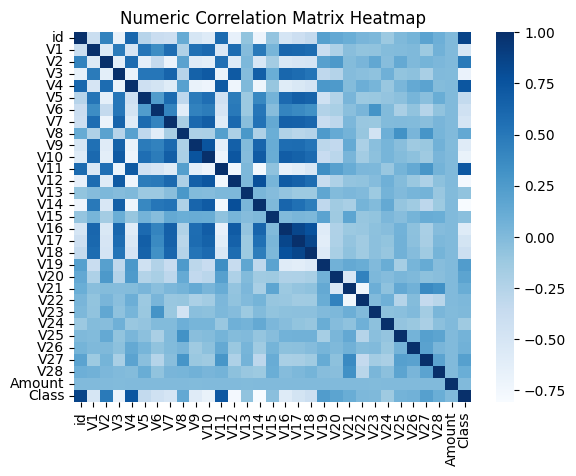

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix
corr_matrix = df.corr(numeric_only=True)
# Plot heatmap
plt.figure()
sns.heatmap(corr_matrix, xticklabels=1, yticklabels=1, cmap='Blues')
plt.title("Numeric Correlation Matrix Heatmap")
plt.show()

In [178]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
  transformers=[
      ('drop_cols', 'drop', 'id')
  ],
  remainder=MinMaxScaler()
)

pipeline = Pipeline([
  ('preprocessor', preprocessor)
])

In [179]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_temp, y_train, y_temp = train_test_split(
  X, y, test_size=0.02, random_state=42, stratify=y
)

X_dev, X_test, y_dev, y_test = train_test_split(
  X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

X_train = pipeline.fit_transform(X_train)
X_dev = pipeline.transform(X_dev)
X_test = pipeline.transform(X_test)

y_train = y_train.to_numpy()
y_dev = y_dev.to_numpy()
y_test = y_test.to_numpy()

print(X_train.shape)
print(X_dev.shape)
print(X_test.shape)

(557257, 29)
(5686, 29)
(5687, 29)


EDA:

Data seems to be in good shape. All numeric data, no missing valus. Lots of data warrants a 98-1-1 split. Seems to be heavy correllation in the first 18 features. Similarly, the final class is also correllated to these. Simple scaling is enough for preprocesisng. We also have an even 50/50 split for class labels.

In [193]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

class NNClassifier(nn.Module):
  def __init__(self, in_dim, out_dim):
    super().__init__()

    self.flatten = nn.Flatten()
    self.fc = nn.Sequential(
      nn.Linear(in_dim, 512),
      nn.ReLU(),
      nn.Linear(512, out_dim),
      nn.Sigmoid()
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.fc(x)
    return logits

In [181]:
def train(dataloader, model, loss_fn, optimizer, device):
  model.train()

  for X, y in dataloader:
    optimizer.zero_grad()
    X, y = X.to(device), y.to(device)

    y_pred = model(X)
    loss = loss_fn(y_pred.view_as(y), y)

    loss.backward()
    optimizer.step()

def test(dataloader, model, loss_fn, device):
  model.eval()

  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  test_loss = 0
  correct = 0
  all_outputs = []

  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)

      y_pred = model(X)

      test_loss += loss_fn(y_pred, y).item()
      y_binary = torch.where(y_pred > 0.5, 1, 0).float()
      correct += (y_binary == y).sum().item()

      preds_np = y_pred.detach().cpu().numpy()
      all_outputs.append(preds_np)

  test_loss /= num_batches
  test_accuracy = correct / size
  all_outputs = np.concatenate(all_outputs, axis=0)

  return test_loss, test_accuracy, all_outputs


TESTING THE FROM-SCRATCH NN

In [182]:
INPUT_DIM = X_train.shape[1]
OUTPUT_DIM = 1
lr = 0.001
num_epoch = 25

In [183]:
dims = [INPUT_DIM, 512, OUTPUT_DIM]

scratch_nn = NeuralNetwork(dims, lr)

In [184]:
import copy

# Reshape for correct output sizes
y_train_rs = np.array(y_train, dtype=float).reshape(-1, 1)
y_dev_rs =   np.array(y_dev, dtype=float).reshape(-1, 1)

scratch_nn = NeuralNetwork(dims, lr)
best_model = copy.deepcopy(scratch_nn)
best_loss = float('inf')

for e in range(25):
    # 10k train size, 200 batch
    scratch_nn.train(X_train[:100000], y_train_rs[:100000], 64)

    # Predict
    y_pred = scratch_nn.predict(X_dev)

    loss_val = np.mean(scratch_nn.cost(y_pred, y_dev_rs))
    y_binary = (y_pred > 0.5).astype(int)
    acc_val = np.mean(y_binary == y_dev_rs)

    print(f"Epoch {e+1}: Dev Loss: {loss_val:.4f}, Dev Accuracy: {acc_val:.4f}")

    if loss_val < best_loss:
        print(f"New best model! Saving...")
        best_model = copy.deepcopy(scratch_nn)
        best_loss = loss_val

Epoch 1: Dev Loss: 0.5237, Dev Accuracy: 0.8906
New best model! Saving...
Epoch 2: Dev Loss: 0.4416, Dev Accuracy: 0.9038
New best model! Saving...
Epoch 3: Dev Loss: 0.3913, Dev Accuracy: 0.9078
New best model! Saving...
Epoch 4: Dev Loss: 0.3564, Dev Accuracy: 0.9093
New best model! Saving...
Epoch 5: Dev Loss: 0.3304, Dev Accuracy: 0.9098
New best model! Saving...
Epoch 6: Dev Loss: 0.3099, Dev Accuracy: 0.9089
New best model! Saving...
Epoch 7: Dev Loss: 0.2932, Dev Accuracy: 0.9096
New best model! Saving...
Epoch 8: Dev Loss: 0.2792, Dev Accuracy: 0.9115
New best model! Saving...
Epoch 9: Dev Loss: 0.2671, Dev Accuracy: 0.9138
New best model! Saving...
Epoch 10: Dev Loss: 0.2567, Dev Accuracy: 0.9165
New best model! Saving...
Epoch 11: Dev Loss: 0.2477, Dev Accuracy: 0.9177
New best model! Saving...
Epoch 12: Dev Loss: 0.2397, Dev Accuracy: 0.9193
New best model! Saving...
Epoch 13: Dev Loss: 0.2326, Dev Accuracy: 0.9196
New best model! Saving...
Epoch 14: Dev Loss: 0.2263, Dev Ac

In [185]:
y_test_rs =   np.array(y_test, dtype=float).reshape(-1, 1)

y_pred = best_model.predict(X_test)

loss_val = np.mean(scratch_nn.cost(y_pred, y_test_rs))
y_binary = (y_pred > 0.5).astype(int)
acc_val = np.mean(y_binary == y_test_rs)

print(f"Test Loss: {loss_val:.4f}, Test Accuracy: {acc_val:.4f}")

Test Loss: 0.1802, Test Accuracy: 0.9397


PART 1 ANALYSIS:

I chose a subset of 10,000 training points with a batch size of 200. While I did correctly implement batch and minibatch gradient descent in fully matrix form, a lower batch size meant more updates to the weights and biases per epoch, which meant a faster convergence. I also used a learning rate of 0.001 which is a standard value, as well as one hidden layer of 512 nodes, which once again is standard. More than one hidden layer is, in theory, not useful because it can just be represented as a larger single layer in the first place. I got a validation accuracy of 93.79% and a test accuracy of 93.97% which are good metrics.

Other notes: I picked my batch size in part to increase speed. I wanted some batch size for the regulatory effect of averaging gradients. A big batch size, as said above, meant less updates, took up more RAM, and was net slower despite my efficient implementation.

In [186]:
from torch.utils.data import Dataset, DataLoader

class BCDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.from_numpy(X).float()
    self.y = torch.from_numpy(y).float().unsqueeze(1)

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [187]:
train_ds = BCDataset(X_train, y_train)
dev_ds = BCDataset(X_dev, y_dev)
test_ds = BCDataset(X_test, y_test)

In [188]:
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dev_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [189]:
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

model = NNClassifier(INPUT_DIM, OUTPUT_DIM).to(device)
loss_func = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

Using cpu device


In [190]:
best_acc = 0
best_model_wts = copy.deepcopy(model.state_dict())

for e in range(num_epoch):
  train(train_loader, model, loss_func, optimizer, device)
  dev_loss, dev_acc, _ = test(dev_loader, model, loss_func, device)
  print(f"Epoch {e+1}: Dev Loss: {dev_loss:.4f}, Dev Accuracy: {dev_acc:.4f}")

  if dev_acc > best_acc:
    best_acc = dev_acc
    best_model_wts = copy.deepcopy(model.state_dict())
    print("New best model! Saving...")

Epoch 1: Dev Loss: 0.1139, Dev Accuracy: 0.9643
New best model! Saving...
Epoch 2: Dev Loss: 0.0932, Dev Accuracy: 0.9655
New best model! Saving...
Epoch 3: Dev Loss: 0.0940, Dev Accuracy: 0.9675
New best model! Saving...
Epoch 4: Dev Loss: 0.0837, Dev Accuracy: 0.9759
New best model! Saving...
Epoch 5: Dev Loss: 0.0692, Dev Accuracy: 0.9794
New best model! Saving...
Epoch 6: Dev Loss: 0.0609, Dev Accuracy: 0.9810
New best model! Saving...
Epoch 7: Dev Loss: 0.0663, Dev Accuracy: 0.9770
Epoch 8: Dev Loss: 0.0507, Dev Accuracy: 0.9865
New best model! Saving...
Epoch 9: Dev Loss: 0.0478, Dev Accuracy: 0.9854
Epoch 10: Dev Loss: 0.0445, Dev Accuracy: 0.9910
New best model! Saving...
Epoch 11: Dev Loss: 0.0420, Dev Accuracy: 0.9924
New best model! Saving...
Epoch 12: Dev Loss: 0.0402, Dev Accuracy: 0.9930
New best model! Saving...
Epoch 13: Dev Loss: 0.0410, Dev Accuracy: 0.9924
Epoch 14: Dev Loss: 0.0410, Dev Accuracy: 0.9923
Epoch 15: Dev Loss: 0.0440, Dev Accuracy: 0.9863
Epoch 16: Dev 

In [191]:
test_loss, test_acc, _ = test(test_loader, model, loss_func, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0326, Test Accuracy: 0.9947


Results were very impressive with an accuracy of well over 99%, which was reached in the validation set by epoch 10.

Accuracy: 99.47% TEST

I selected the learning rate to be a fairly standard and accepted parameter. Too high yields noise, too low yields slow training. 0.001 is a fairly standard value. I did not choose any regulartory features like dropout, weight decay, etc. because I felt one hidden layer of 512 size was modest enough to avoid overfitting. My accuracy and consistent improvements in the dev set accuracy justify this reasoning.

I chose to use the Adam optimizer. It yields faster convergence, adapts learning rates, and generally is just a no-brainer to include for any neural network training.

Once again, I chose batch gradient descent. I chose a lower batch size to maximize the number of weight updates we had. I avoided pure stochastic (hence the minibatch) to avoid its noisy updates.

I used MinMaxScaler to "normalize" the data. I did not use any form of z-score or gaussian-based normalization techniques. Generally, the model performed better with normalization rather than not. This is likely due to the ability for the model to equally weight influence of each feature.

### Task 4

In [192]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression()
log.fit(X_train, y_train)

y_pred = log.predict(X_test)
y_binary = np.where(y_pred > 0.5, 1, 0)
test_acc = np.mean(y_binary == y_test)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9603


Since we are doing binary classification, logreg is an ideal baseline. This obtained an accuracy of 96.03% without any hyperparameter tuning.

This is better than my neural network implementation but worse than the PyTorch one. Logreg is fairly simple in regards to its classification boundary. The fact that it performed worse than the neural network usually makes sense as the neural network can make much more specific classification boundaries. Naturally, it can also overfit. The fact it stayed at the 99% accuracy region while the logreg accuracy was closer to 96% likely implies that the classification boundary is on the more complex side s.t. a neural network better encompasses it without getting into the realm of overfitting.

Why did my from-scratch perform worse? Likely it needs more training time. It doesn't have the same optimization power as the PyTorch model. On one run I did get north of 96% accuracy, but the final run in this submission does not have that.